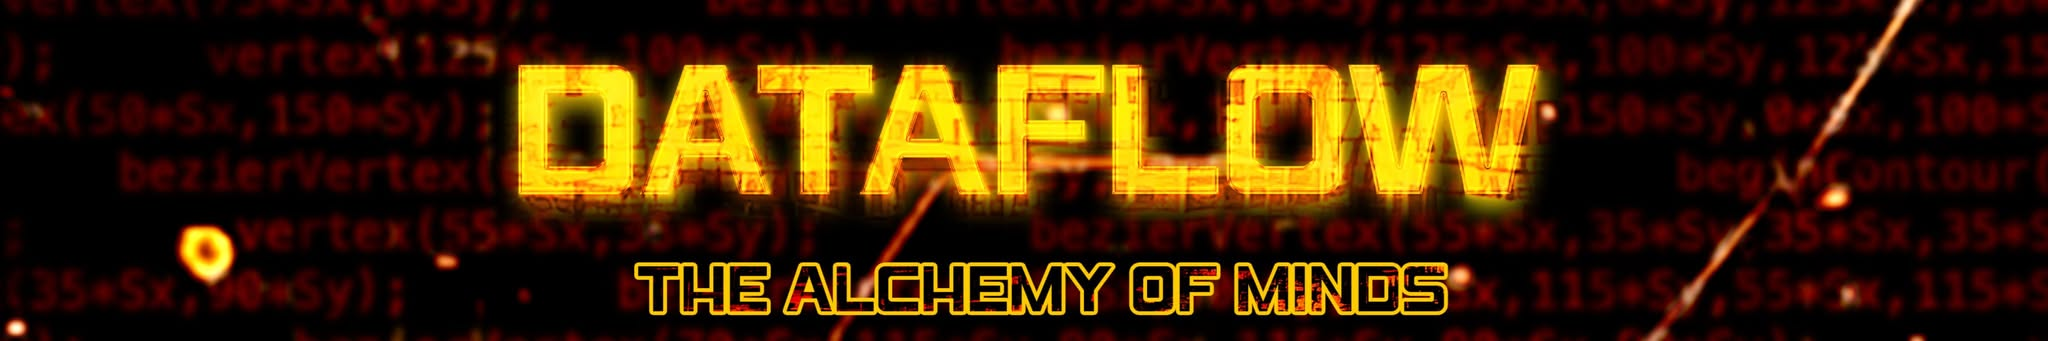

## Starter Notebook
**Xây dựng Mô hình Phân loại Đa đầu ra (Multi-output Classifier) cho Bài toán Dự đoán hành vi người dùng (User Behavior Prediction)**

## Giới thiệu

Chào mừng bạn đến với DATAFLOW 2026!


Trong notebook khởi động này, chúng tôi sẽ hướng dẫn bạn quy trình xây dựng một baseline đơn giản bằng thuật toán `RandomForestClassifier` để dự báo đồng thời 6 thuộc tính hành vi mục tiêu. Notebook này được thiết kế để giúp bạn có thể chạy nội bộ (Local) hoặc trên nền tảng (Colab / Kaggle).

### Nội dung chính:

1.  **Môi trường & Thư viện:** Cài đặt và import các thư viện nền tảng cơ bản.
2.  **Load Dữ liệu:** Đọc bộ dữ liệu Train, Validation và Test.
3.  **Tiền xử lý:** Xử lý dữ liệu thiếu (missing values) và tạo tập features.
4.  **Huấn luyện Mô hình:** Huấn luyện mô hình Random Forest cơ bản.
5.  **Đánh giá:** Tính toán chỉ số Exact-Match Accuracy.
6.  **Tạo File Nộp Bài:** Dự đoán tập Test và xuất file `submission.csv`.

**Lưu ý trước khi bắt đầu:**
* Hãy đảm bảo bạn đã tải bộ dữ liệu từ nền tảng cuộc thi trên Kaggle và đặt vào thư mục `dataset/` tương ứng như đã hướng dẫn trong `README.md`.

In [9]:
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## 1. Load Dữ liệu

In [10]:
DATA_DIR = '../dataset/'

X_train = pd.read_csv(os.path.join(DATA_DIR, 'X_train.csv'))
Y_train = pd.read_csv(os.path.join(DATA_DIR, 'Y_train.csv'))
X_val   = pd.read_csv(os.path.join(DATA_DIR, 'X_val.csv'))
Y_val   = pd.read_csv(os.path.join(DATA_DIR, 'Y_val.csv'))
X_test  = pd.read_csv(os.path.join(DATA_DIR, 'X_test.csv'))

## 2. Tiền xử lý

In [11]:
FEATURE_COLS = [f'feature_{i}' for i in range(1, 37)]
TARGET_COLS  = ['attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6']
ID_COL       = 'id'

col_means = X_train[FEATURE_COLS].mean()

X_train_feat = X_train[FEATURE_COLS].fillna(col_means).values
X_val_feat   = X_val[FEATURE_COLS].fillna(col_means).values
X_test_feat  = X_test[FEATURE_COLS].fillna(col_means).values

Y_train_arr = Y_train[TARGET_COLS].values
Y_val_arr   = Y_val[TARGET_COLS].values

## 3. Huấn luyện Mô hình

In [12]:
models = {}

for attr in TARGET_COLS:
    idx = TARGET_COLS.index(attr)
    y_tr = Y_train_arr[:, idx]

    clf = RandomForestClassifier(random_state=42, n_jobs=-1)
    clf.fit(X_train_feat, y_tr)
    models[attr] = clf

## 4. Đánh giá trên Tập Validation

In [13]:
print('Đang dự đoán tập validation...')
pred_val = np.column_stack([
    models[attr].predict(X_val_feat) for attr in TARGET_COLS
])

exact_matches = np.all(pred_val == Y_val_arr, axis=1).sum()
exact_match_acc = exact_matches / len(Y_val_arr) * 100

print(f'Exact Match Accuracy: {exact_match_acc:.2f}%')

Đang dự đoán tập validation...
Exact Match Accuracy: 13.88%


## 5. Tạo File Submission

In [14]:
test_userids = X_test[ID_COL].values

pred_test = np.column_stack([
    models[attr].predict(X_test_feat) for attr in TARGET_COLS
])

submission = pd.DataFrame(pred_test, columns=TARGET_COLS)
submission.insert(0, ID_COL, test_userids)

output_path = 'submission.csv'
submission.to_csv(output_path, index=False)

print(submission.head())

      id  attr_1  attr_2  attr_3  attr_4  attr_5  attr_6
0  gpbfd      11       1      84      12       1      96
1  w22ee       9      17      44       3      14       9
2  wyw95       1       1      98       3       1      53
3  izx4w       5       1      72       1       1      77
4  c6o2d      11       1      22      12       1       2
